# Домашнее задание: Создание Multi-Task классификатора токсичности (Энкодеры)

Добро пожаловать на продвинутое домашнее задание по трансформерным энкодерам! 

В этом задании вам предстоит пройти весь путь создания production-ready NLP модели: от формализации бизнес-задачи и сбора данных до обучения Multi-Task энкодера с ранней остановкой и деплоя готового решения на Hugging Face.

Вам предстоит создать модель, которая будет одновременно предсказывать три независимых класса токсичности для одного текста:
1. Ненормативная лексика (Profanity)
2. Угрозы (Threats)
3. Запросы на нарушение закона (Illegal acts, например, "как создать бомбу")

---

## Часть 1: Формализация задачи (10 баллов)

Представьте, что вы работаете в социальной сети или платформе для общения. Бизнес пришел к вам с запросом: "Нам нужно автоматически фильтровать и помечать токсичные комментарии пользователей по трем категориям, чтобы модераторы могли быстрее реагировать на угрозы, а алгоритмы могли автоматически скрывать мат".

**Задание 1.1: Бизнес-метрики (3 балла)**
Предложите 2-3 бизнес-метрики, которые будет оптимизировать ваше решение. Оцифруйте их (например, "снижение времени реакции модератора на...").


In [ ]:
# TODO: Опишите бизнес-метрики


**Задание 1.2: Сведение к ML-задаче (3 балла)**
Сведите бизнес-задачу к ML-задаче. Опишите:
- Тип задачи (какая это классификация?)
- Объект (что подается на вход?)
- Метки (в каком формате модель выдает ответ?)


In [ ]:
# TODO: Опишите ML-задачу


**Задание 1.3: ML-метрики (4 балла)**
Предложите оффлайн метрики для оценки качества модели. Учтите, что классы могут быть сильно несбалансированы (мат встречается часто, а запросы на нарушение закона — редко).


In [ ]:
# TODO: Опишите ML-метрики


---

## Часть 2: Сбор, очистка и аналитика датасета (15 баллов)

Вам необходимо собрать датасет для обучения. Вы можете использовать готовые открытые датасеты (например, `Kaggle Toxic Comment Classification Challenge`, переведенный на русский, или русскоязычные датасеты вроде `ru_toxic_comments`). 

**Задание 2.1: Сбор и очистка (7 баллов)**
Загрузите данные (минимум 5000 примеров). Очистите текст от ссылок, HTML-тегов и лишних символов. Приведите метки к формату трех бинарных колонок: `profanity`, `threat`, `illegal`.


In [ ]:
import pandas as pd
import re
# TODO: Загрузка и очистка данных


**Задание 2.2: Аналитика и дисбаланс (8 баллов)**
Постройте графики распределения классов (bar chart). Оцените дисбаланс. Постройте матрицу корреляции между классами (пересекаются ли угрозы с матом?).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# TODO: Аналитика датасета


---

## Часть 3: Публикация датасета на Hugging Face (5 баллов)

**Задание 3.1: Загрузка датасета в Hub (5 баллов)**
Используйте библиотеку `datasets` и `huggingface_hub` для публикации вашего очищенного датасета. Обязательно создайте базовую Dataset Card.
*Подсказка: используйте `notebook_login()` для авторизации.*


In [ ]:
from datasets import Dataset
from huggingface_hub import notebook_login
# TODO: Публикация датасета


---

## Часть 4: Архитектура Multi-Task Энкодера (20 баллов)

Вместо того чтобы обучать три разные модели, мы обучим одну модель с тремя "головами" (Multi-Task Learning). Это сэкономит память и ускорит инференс.

**Задание 4.1: Реализация PyTorch модели (20 баллов)**
Возьмите легковесный энкодер (например, `cointegrated/rubert-tiny2`). Напишите класс-наследник `nn.Module`. 
Модель должна:
1. Пропускать текст через энкодер.
2. Извлекать эмбеддинг `[CLS]` токена.
3. Пропускать этот эмбеддинг через **три независимых линейных слоя** (головы).
4. Возвращать три логита (до применения сигмоиды).


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer

class MultiTaskToxicityEncoder(nn.Module):
    def __init__(self, model_name="cointegrated/rubert-tiny2"):
        super().__init__()
        # TODO: Инициализация энкодера и трех линейных слоев
        
    def forward(self, input_ids, attention_mask):
        # TODO: Извлечение [CLS] токена и проход через три головы
        pass


---

## Часть 5: Обучение с ранней остановкой (Early Stopping) (20 баллов)

**Задание 5.1: Тренировочный цикл (20 баллов)**
Напишите цикл обучения. 
- Используйте `BCEWithLogitsLoss` для каждой головы. Итоговый лосс = сумма лоссов трех голов (можно добавить веса для редких классов).
- Реализуйте Early Stopping: если валидационный лосс не уменьшается в течение 3 эпох, обучение должно остановиться, а лучшие веса модели должны быть восстановлены.


In [ ]:
# TODO: Написание Dataset, DataLoader и тренировочного цикла с Early Stopping


---

## Часть 6: Оценка, пороги и визуализация ошибок (20 баллов)

Модель выдает вероятности. Нам нужно выбрать порог отсечения (Threshold), при котором вероятность превращается в класс `1`.

**Задание 6.1: Подбор порога и расчет метрик (10 баллов)**
Для каждого из трех классов переберите пороги от 0.1 до 0.9. Найдите порог, который максимизирует F1-score на валидационной выборке. Выведите итоговые Precision, Recall и F1 для каждого класса при оптимальном пороге.


In [ ]:
from sklearn.metrics import precision_recall_fscore_support
# TODO: Подбор порога и расчет метрик


**Задание 6.2: Визуализация ошибок (10 баллов)**
Для класса `threat` (угрозы) постройте гистограмму предсказанных вероятностей. Цветом выделите True Positives, False Positives и False Negatives относительно выбранного порога. Это поможет бизнесу понять, насколько модель "уверена" когда ошибается.

**Пример хорошей визуализации:**
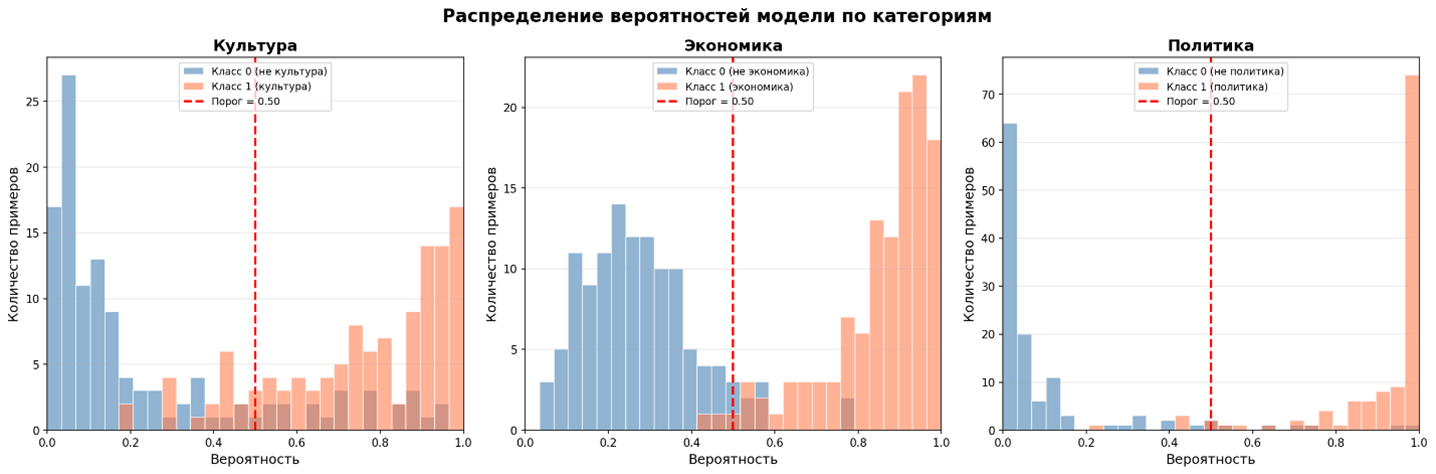


In [ ]:
# TODO: Визуализация распределения вероятностей и ошибок


---

## Часть 7: Инференс и ручное тестирование (10 баллов)

**Задание 7.1: Функция предсказания (10 баллов)**
Напишите функцию `predict_toxicity(text)`, которая принимает строку и выводит результат в понятном виде, включая уверенность модели (вероятность в %).
Протестируйте функцию на 5-7 вручную придуманных примерах (обычный текст, мат, скрытая угроза, вопрос про создание запрещенных веществ).


In [ ]:
def predict_toxicity(text):
    # TODO: Реализация инференса с использованием найденных порогов
    pass

# Тестирование
texts = [
    "Привет, как дела? Отличная погода!",
    # TODO: Добавьте свои примеры
]


---

## Часть 8: Публикация модели на Hugging Face (10 баллов)

**Задание 8.1: Публикация модели (10 баллов)**
Сохраните веса вашей обученной модели и токенизатор. Загрузите их в свой репозиторий на Hugging Face Hub. Напишите небольшую Model Card, где укажете метрики и пример использования.


In [ ]:
# TODO: Публикация модели на HF Hub


---
**Поздравляем! Вы прошли полный цикл создания NLP-решения на базе трансформерных энкодеров.**
